In [19]:
import numpy as np
from numpy.random import rand
import matplotlib.pyplot as plt

In [5]:
X=np.array(([0.9,0.8],[0.6,0.3],[0.9,0.1],[0.9,0.8]))
Y=np.array(([0],[1],[1],[0]))

In [13]:
def sigmoid(z):
  return 1/(1+np.exp(-z))


class NeuralNetwork:
  def __init__(self,x,y,nodes_in_layer1=4,nodes_in_layer2=3,nodes_in_layer3=1,l_rate=1):

    self.inputs_in_layer0=x
    self.y=y

    self.nodes_in_layer1=nodes_in_layer1
    self.nodes_in_layer2=nodes_in_layer2
    self.nodes_in_layer3=nodes_in_layer3
    self.l_rate=l_rate # Added this line to initialize l_rate

    self.thetas_layer0=np.random.rand(self.inputs_in_layer0.shape[1]+1,self.nodes_in_layer1)
    self.thetas_layer1=np.random.rand(self.nodes_in_layer1 + 1,self.nodes_in_layer2)
    self.thetas_layer2=np.random.rand(self.nodes_in_layer2 + 1,self.nodes_in_layer3)

  def feedforward(self):

    self.Z1=self.thetas_layer0[0]+np.dot(self.inputs_in_layer0,self.thetas_layer0[1:])
    self.layer1=sigmoid(self.Z1)

    self.Z2=self.thetas_layer1[0]+np.dot(self.layer1,self.thetas_layer1[1:])
    self.layer2=sigmoid(self.Z2)

    self.Z3=self.thetas_layer2[0]+np.dot(self.layer2,self.thetas_layer2[1:])
    self.layer3=sigmoid(self.Z3)

    return self.layer3

  def cost_func(self):

    self.n=self.inputs_in_layer0.shape[0]
    self.cost=(1/self.n)*np.sum(-self.y*np.log(self.layer3)-(1-self.y)*np.log(1-self.layer3))
    return self.cost

  def backprop(self):
    #layer2
    self.dE_dlayer3=(1/self.n)*(self.layer3-self.y)/(self.layer3*(1-self.layer3))
    self.dE_dZ3=np.multiply(self.dE_dlayer3,(sigmoid(self.Z3)*(1-sigmoid(self.Z3))))
    self.dE_dtheta2=np.dot(self.layer2.T,self.dE_dZ3)
    self.dE_dbais2=np.dot(np.ones(self.n),self.dE_dZ3)

    #layer1
    self.dE_dlayer2=np.dot(self.dE_dZ3,self.thetas_layer2[1:].T)
    self.dE_dZ2=np.multiply(self.dE_dlayer2,(sigmoid(self.Z2)*(1-sigmoid(self.Z2))))
    self.dE_dtheta1=np.dot(self.layer1.T,self.dE_dZ2)
    self.dE_dbais1=np.dot(np.ones(self.n),self.dE_dZ2)

    #layer0
    self.dE_dlayer1=np.dot(self.dE_dZ2,self.thetas_layer1[1:].T)
    self.dE_dZ1=np.multiply(self.dE_dlayer1,(sigmoid(self.Z1)*(1-sigmoid(self.Z1))))
    self.dE_dtheta0=np.dot(self.inputs_in_layer0.T,self.dE_dZ1)
    self.dE_dbais0=np.dot(np.ones(self.n),self.dE_dZ1)

    self.thetas_layer2[1:]=self.thetas_layer2[1:]-self.l_rate*self.dE_dtheta2
    self.thetas_layer1[1:]=self.thetas_layer1[1:]-self.l_rate*self.dE_dtheta1
    self.thetas_layer0[1:]=self.thetas_layer0[1:]-self.l_rate*self.dE_dtheta0

    self.thetas_layer2[0]=self.thetas_layer2[0]-self.l_rate*self.dE_dbais2
    self.thetas_layer1[0]=self.thetas_layer1[0]-self.l_rate*self.dE_dbais1
    self.thetas_layer0[0]=self.thetas_layer0[0]-self.l_rate*self.dE_dbais0

    return self

In [17]:
NN=NeuralNetwork(X,Y)
epoch=1000
losses=[]
for i in range(epoch):
  predicted_output=NN.feedforward()
  error=NN.cost_func()
  losses.append(error)
  u=NN.backprop()
  print("iteration # ",i+1)
  print("Actual Output: \n",Y)
  print("Predicted Output: \n",predicted_output,"\n")
  print("cost: \n",error)

Streaming output truncated to the last 5000 lines.
cost: 
 0.013215415605803653
iteration #  644
Actual Output: 
 [[0]
 [1]
 [1]
 [0]]
Predicted Output: 
 [[0.01083766]
 [0.97759165]
 [0.99187927]
 [0.01083766]] 

cost: 
 0.013152689395822429
iteration #  645
Actual Output: 
 [[0]
 [1]
 [1]
 [0]]
Predicted Output: 
 [[0.01078547]
 [0.97769561]
 [0.99191582]
 [0.01078547]] 

cost: 
 0.013090510187315323
iteration #  646
Actual Output: 
 [[0]
 [1]
 [1]
 [0]]
Predicted Output: 
 [[0.01073373]
 [0.97779868]
 [0.99195206]
 [0.01073373]] 

cost: 
 0.01302887111230206
iteration #  647
Actual Output: 
 [[0]
 [1]
 [1]
 [0]]
Predicted Output: 
 [[0.01068244]
 [0.97790087]
 [0.991988  ]
 [0.01068244]] 

cost: 
 0.012967765414486212
iteration #  648
Actual Output: 
 [[0]
 [1]
 [1]
 [0]]
Predicted Output: 
 [[0.0106316 ]
 [0.97800221]
 [0.99202363]
 [0.0106316 ]] 

cost: 
 0.012907186447038508
iteration #  649
Actual Output: 
 [[0]
 [1]
 [1]
 [0]]
Predicted Output: 
 [[0.0105812 ]
 [0.97810268]
 [0

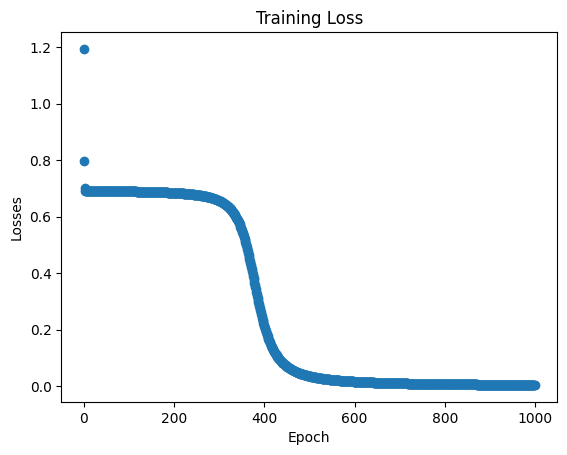

In [21]:
plt.scatter(range(epoch),losses)
plt.title("Training Loss")
plt.xlabel('Epoch')
plt.ylabel("Losses")
plt.show()